# 02 — Préprocessing : nettoyage, fusion labo, feature engineering, séquences

Ce notebook applique et documente le pipeline de `src/preprocessing.py`, réutilisé tel quel
par le backend pour l'inférence. Étapes : imputation temporelle, clipping des outliers,
correction de dérive capteur, jointure asof avec le labo (délai de 4 h, **zéro fuite de
données**), feature engineering, construction des séquences, split temporel strict 70/15/15,
et normalisation `StandardScaler` ajustée uniquement sur le train.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config_loader import load_config, resolve_path
from src import preprocessing as pp

cfg = load_config("../config.yaml")
FIG_DIR = resolve_path(cfg["paths"]["figures_dir"])
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

tables = pp.load_raw_tables(cfg)
cdu_raw = tables["cdu"]
print("cdu_data brut :", cdu_raw.shape, "| % manquants moyen :", cdu_raw.isna().mean().mean().round(4))

cdu_data brut : (17544, 12) | % manquants moyen : 0.0091


## 1. Imputation temporelle + clipping des outliers

Valeurs manquantes après imputation : 0


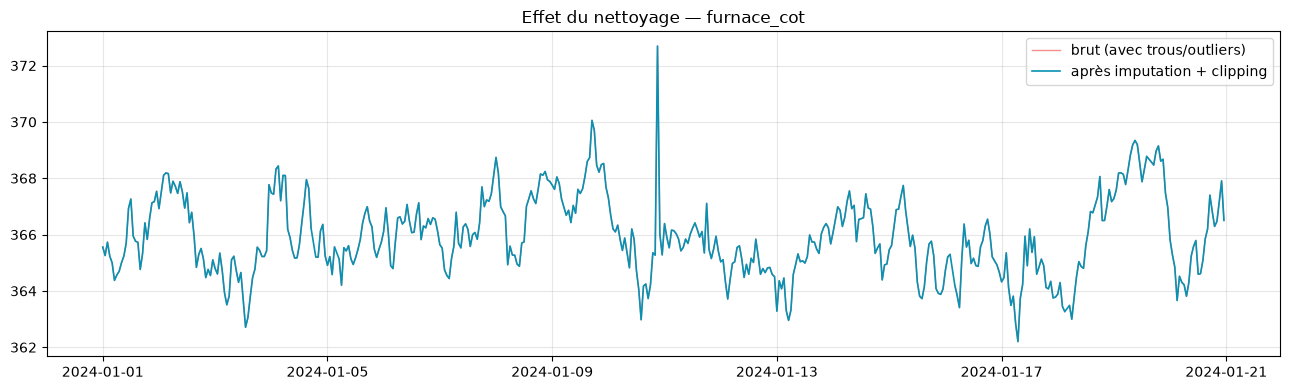

In [2]:
numeric_cols = [c for c in cdu_raw.columns if c != "crude_type"]
cdu_imputed = pp.impute_missing_temporal(cdu_raw, numeric_cols)
cdu_clipped = pp.clip_outliers_iqr(cdu_imputed, numeric_cols, k=cfg["preprocessing"]["outlier_iqr_k"])

print("Valeurs manquantes après imputation :", cdu_imputed[numeric_cols].isna().sum().sum())

col = "furnace_cot"
window = slice("2024-01-01", "2024-01-20")
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(cdu_raw.loc[window].index, cdu_raw.loc[window, col], label="brut (avec trous/outliers)",
        color="#ef4444", alpha=0.6, linewidth=1.0)
ax.plot(cdu_clipped.loc[window].index, cdu_clipped.loc[window, col], label="après imputation + clipping",
        color="#0891b2", linewidth=1.2)
ax.set_title(f"Effet du nettoyage — {col}")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "02_imputation_clipping.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (1.)** — L'interpolation temporelle comble les trous sans casser la dynamique
locale, et le clipping IQR ramène les outliers dans une plage plausible sans les supprimer
(préservation de la fréquence horaire régulière, indispensable pour les modèles séquentiels).

## 2. Correction de la dérive capteur

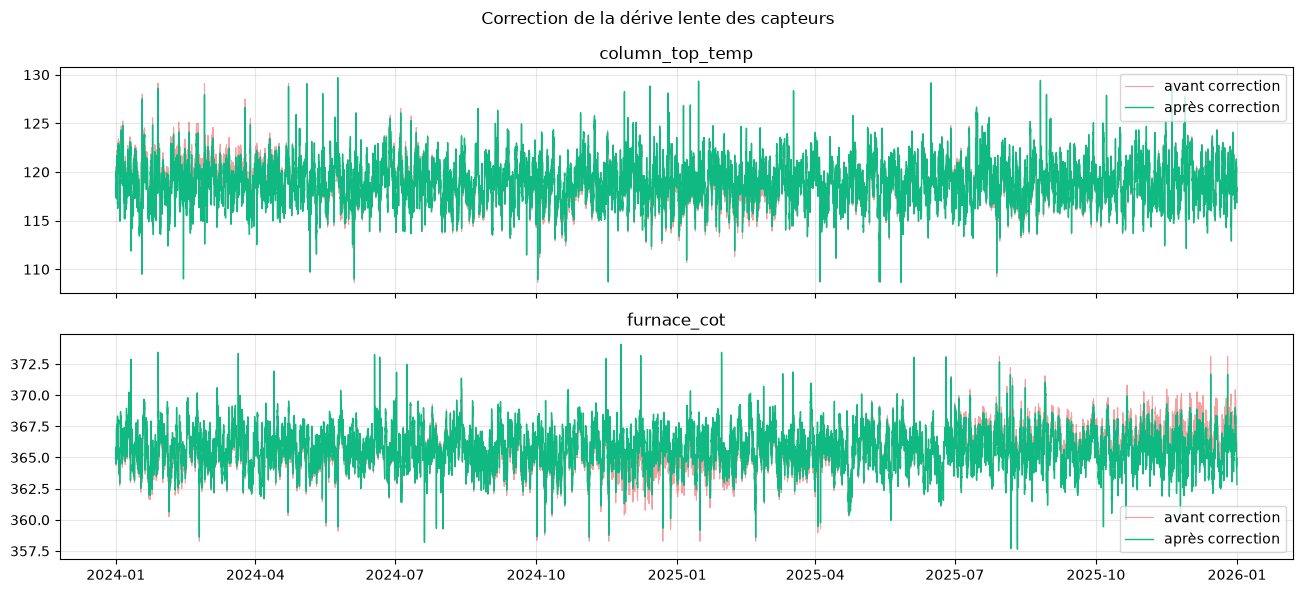

In [3]:
cdu_drift_corrected = pp.correct_sensor_drift(cdu_clipped, cfg["data_generator"]["cdu"]["drift_sensors"])

fig, axes = plt.subplots(len(cfg["data_generator"]["cdu"]["drift_sensors"]), 1, figsize=(13, 6), sharex=True)
for ax, sensor in zip(axes, cfg["data_generator"]["cdu"]["drift_sensors"]):
    ax.plot(cdu_clipped.index, cdu_clipped[sensor], label="avant correction", color="#ef4444", alpha=0.5, linewidth=0.8)
    ax.plot(cdu_drift_corrected.index, cdu_drift_corrected[sensor], label="après correction", color="#10b981", linewidth=1.0)
    ax.set_title(sensor)
    ax.legend()
fig.suptitle("Correction de la dérive lente des capteurs")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_drift_correction.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (2.)** — La médiane glissante longue (≈45 jours) isole la composante basse
fréquence (dérive de calibration) sans affecter la dynamique opératoire rapide, qui reste
intacte après correction.

## 3. Jointure asof avec le labo — zéro fuite de données

In [4]:
lab = tables["lab"]
example = lab.iloc[10]
print("Exemple d'échantillon labo :")
print(f"  Prélevé à   : {example['sample_time']}")
print(f"  Résultat dispo à : {example['result_time']}  (délai = 4h)")
print()
print("=> Pour toute donnée horaire à un instant t < result_time, ce résultat est INCONNU")
print("   et ne doit donc PAS être utilisé comme feature (merge_asof direction='backward' sur result_time).")

merged_demo = pp.merge_lab_asof(cdu_drift_corrected.join(tables["energy"].drop(columns=pp.HIDDEN_ENERGY_COLS)), lab)
demo_window = merged_demo.loc["2024-01-01 00:00:00":"2024-01-01 12:00:00", ["sulfur_content"]]
print()
print(demo_window)

Exemple d'échantillon labo :
  Prélevé à   : 2024-01-04 08:00:00
  Résultat dispo à : 2024-01-04 12:00:00  (délai = 4h)

=> Pour toute donnée horaire à un instant t < result_time, ce résultat est INCONNU
   et ne doit donc PAS être utilisé comme feature (merge_asof direction='backward' sur result_time).

                     sulfur_content
timestamp                          
2024-01-01 00:00:00        2.045279
2024-01-01 01:00:00        2.045279
2024-01-01 02:00:00        2.045279
2024-01-01 03:00:00        2.045279
2024-01-01 04:00:00        2.045279
2024-01-01 05:00:00        2.045279
2024-01-01 06:00:00        2.045279
2024-01-01 07:00:00        2.045279
2024-01-01 08:00:00        2.045279
2024-01-01 09:00:00        2.045279
2024-01-01 10:00:00        2.045279
2024-01-01 11:00:00        2.045279
2024-01-01 12:00:00        1.893929


**Conclusion (3.)** — La colonne `sulfur_content` (et les autres variables labo) reste
constante entre deux résultats *disponibles*, et ne change qu'après `result_time`, jamais
avant : le pipeline respecte strictement le délai opérationnel de 4 h, condition nécessaire
pour éviter toute fuite d'information du futur vers le passé.

## 4. Feature engineering

In [5]:
master, hidden_df = pp.build_master_table(cfg)
print("Table maîtresse :", master.shape)
print("Colonnes (extrait) :", list(master.columns[:20]))
print()
print("Colonnes cachées (jamais en feature) :", list(hidden_df.columns))
master.filter(like="furnace_cot").head()

Table maîtresse : (17544, 83)
Colonnes (extrait) : ['feed_rate', 'crude_api', 'furnace_cot', 'column_top_temp', 'column_top_pressure', 'reflux_ratio', 'stripping_steam', 'naphtha_yield', 'kerosene_yield', 'gasoil_yield', 'residue_yield', 'preheat_outlet_temp', 'fuel_gas_flow', 'furnace_duty', 'specific_energy', 'co2_emissions', 'naphtha_final_boiling_point', 'kerosene_flash_point', 'gasoil_cetane_index', 'residue_viscosity']

Colonnes cachées (jamais en feature) : ['fouling_resistance', 'is_cleaning_event', 'cleaning_needed_within_24h', 'cleaning_needed_within_48h']


,furnace_cot,furnace_cot_lag1h,furnace_cot_lag3h,furnace_cot_lag6h,furnace_cot_roll_mean_6h,furnace_cot_roll_std_6h,furnace_cot_roll_mean_24h,furnace_cot_roll_std_24h,furnace_cot_delta1h
timestamp,,,,,,,,,
2024-01-01 00:00:00,365.644068,365.644068,365.644068,365.644068,365.644068,0.000000,365.644068,0.000000,0.000000
2024-01-01 01:00:00,365.345728,365.644068,365.644068,365.644068,365.494898,0.210959,365.494898,0.210959,-0.298340
2024-01-01 02:00:00,365.827003,365.345728,365.644068,365.644068,365.605600,0.242933,365.605600,0.242933,0.481275
2024-01-01 03:00:00,365.334496,365.827003,365.644068,365.644068,365.537824,0.240247,365.537824,0.240247,-0.492507
2024-01-01 04:00:00,365.100067,365.334496,365.345728,365.644068,365.450272,0.285684,365.450272,0.285684,-0.234429


**Conclusion (4.)** — Le feature engineering ajoute des lags (1/3/6h), des moyennes/écarts-types
glissants (6h/24h), des deltas, et un encodage one-hot du type de brut. Les colonnes de
`hidden_df` (résistance d'encrassement, labels de nettoyage) restent strictement séparées de
la table de features — elles ne servent qu'à construire les cibles d'évaluation (notebook 04).

## 5. Construction des séquences (fenêtres glissantes)

In [6]:
window_y = cfg["preprocessing"]["yield_window_hours"]
window_f = cfg["preprocessing"]["fouling_window_hours"]

Xy, yy, feat_cols_y, ts_y = pp.build_yield_sequences(master, window_y)
print(f"Séquences rendements : fenêtre {window_y}h -> X={Xy.shape}, y={yy.shape} (4 rendements à t+1)")

fdata = pp.build_fouling_sequences(master, hidden_df, window_f,
                                    clean_period_hours=cfg["alerts"]["fouling_warning_days"] * 24 * 3)
print(f"Séquences fouling    : fenêtre {window_f}h -> X={fdata['X'].shape}, "
      f"fraction périodes propres = {fdata['is_clean'].mean():.3f}")

Séquences rendements : fenêtre 24h -> X=(17519, 24, 83), y=(17519, 4) (4 rendements à t+1)


Séquences fouling    : fenêtre 48h -> X=(17496, 48, 83), fraction périodes propres = 0.050


**Conclusion (5.)** — La fenêtre de 24 h pour les rendements est cohérente avec
l'autocorrélation observée en notebook 01 (ACF/PACF). La fenêtre de 48 h pour le fouling
capture un cycle diurne complet x2, utile pour détecter une dérive lente de température.

## 6. Split temporel strict (70/15/15, sans shuffle) + normalisation

Split rendements -> train=12263  val=2627  test=2629
Dates train : 2024-01-02 01:00:00 -> 2025-05-26 23:00:00
Dates val   : 2025-05-27 00:00:00 -> 2025-09-13 10:00:00
Dates test  : 2025-09-13 11:00:00 -> 2025-12-31 23:00:00



Scaler ajusté sur train uniquement — moyenne (5 premières features) : [1323.647   30.692  365.697  118.911    1.801]


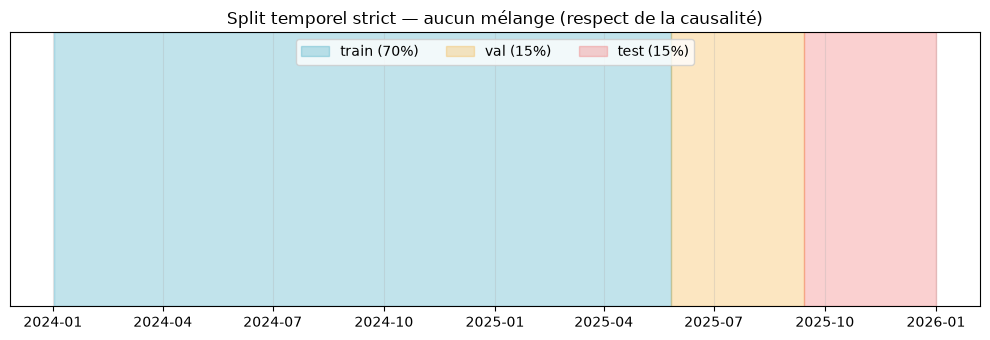

In [7]:
ratios = cfg["preprocessing"]["split_ratios"]
tr, va, te = pp.temporal_split_indices(len(Xy), ratios)
print(f"Split rendements -> train={tr.stop-tr.start}  val={va.stop-va.start}  test={te.stop-te.start}")
print(f"Dates train : {ts_y[tr.start]} -> {ts_y[tr.stop-1]}")
print(f"Dates val   : {ts_y[va.start]} -> {ts_y[va.stop-1]}")
print(f"Dates test  : {ts_y[te.start]} -> {ts_y[te.stop-1]}")

Xy_train, Xy_val, Xy_test, scaler_y = pp.fit_scale_sequences(Xy[tr], Xy[va], Xy[te])
print("\nScaler ajusté sur train uniquement — moyenne (5 premières features) :",
      np.round(scaler_y.mean_[:5], 3))

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axvspan(ts_y[tr.start], ts_y[tr.stop - 1], color="#0891b2", alpha=0.25, label="train (70%)")
ax.axvspan(ts_y[va.start], ts_y[va.stop - 1], color="#f59e0b", alpha=0.25, label="val (15%)")
ax.axvspan(ts_y[te.start], ts_y[te.stop - 1], color="#ef4444", alpha=0.25, label="test (15%)")
ax.set_yticks([])
ax.set_title("Split temporel strict — aucun mélange (respect de la causalité)")
ax.legend(loc="upper center", ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_split_temporel.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (6.)** — Le split respecte l'ordre chronologique (train < val < test, sans
shuffle) pour éviter toute fuite d'information future. Le `StandardScaler` n'est ajusté que
sur le train, puis appliqué tel quel à val/test — pratique standard pour une évaluation non biaisée.

## 7. Exécution complète du pipeline et sauvegarde des artefacts

In [8]:
results = pp.run_preprocessing(cfg)
print("\nArtefacts prêts dans data/processed/ pour les notebooks 03 (rendements) et 04 (fouling).")

[preprocessing] Rendements : X=(17519, 24, 83), y=(17519, 4) -> train=12263 val=2627 test=2629
[preprocessing] Fouling    : X=(17496, 48, 83) -> train=12247 val=2624 test=2625
[preprocessing] Artefacts sauvegardés dans /home/wailbmg/Projects/refinery/data/processed

Artefacts prêts dans data/processed/ pour les notebooks 03 (rendements) et 04 (fouling).


## Conclusion générale

Le pipeline transforme les 4 tables brutes en jeux de séquences propres, normalisés et
temporellement cohérents, prêts pour l'entraînement des réseaux de neurones (notebooks 03 à 06).
Aucune fuite de données n'est introduite (labo respecté à 4h, split strict, scaler fit sur train).